Exploratory Data Analysis (EDA) Cell

Dataset Shape: (30641, 14)

First 5 rows:


,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75



Missing Values:
Gender                    0
EthnicGroup            1840
ParentEduc             1845
LunchType                 0
TestPrep               1830
ParentMaritalStatus    1190
PracticeSport           631
IsFirstChild            904
NrSiblings             1572
TransportMeans         3134
WklyStudyHours          955
MathScore                 0
ReadingScore              0
WritingScore              0
dtype: int64


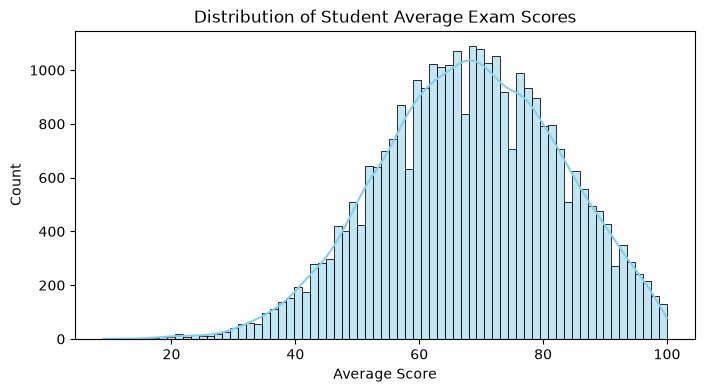

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the expanded dataset
df = pd.read_csv('data/Expanded_data_with_more_features.csv')

# Drop any unneeded index columns if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

# Create a Total Score column
df['TotalScore'] = df['MathScore'] + df['ReadingScore'] + df['WritingScore']
df['AverageScore'] = df['TotalScore'] / 3

# Quick EDA Plot
plt.figure(figsize=(8, 4))
sns.histplot(df['AverageScore'], kde=True, color='skyblue')
plt.title("Distribution of Student Average Exam Scores")
plt.xlabel("Average Score")
plt.ylabel("Count")
plt.show()

Feature Engineering & Model Comparison Cell


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np
import joblib

# Safely handle any missing values
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        # If it's a number, fill with the average
        df[col] = df[col].fillna(df[col].mean())
    else:
        # If it's text/categorical, fill with the most common value
        df[col] = df[col].fillna(df[col].mode()[0])

# Define Features and Target
# We predict MathScore based on demographics and behavioral features
features = [
    'Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep', 
    'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild', 'NrSiblings', 
    'TransportMeans', 'WklyStudyHours', 'ReadingScore', 'WritingScore'
]
target = 'MathScore'

# Keep only columns that exist in the dataset
features = [f for f in features if f in df.columns]

X = df[features]
y = df[target]

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(exclude=['number']).columns.tolist()
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models to compare (this is the core of your resume bullet point!)
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, learning_rate=0.1)
}

print("--- Model Comparison Results ---")
best_score = -float('inf')
best_pipeline = None
best_model_name = ""

for name, model in models.items():
    # Bundle preprocessor and model in a pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    
    # Train the model
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipeline.predict(X_test)
    
    # Evaluate
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"{name:20} -> R² Score: {r2:.4f} | RMSE: {rmse:.2f}")
    
    # Keep track of the best performing model
    if r2 > best_score:
        best_score = r2
        best_pipeline = pipeline
        best_model_name = name

print(f"\nBest Model: {best_model_name} with R²: {best_score:.4f}")

# Save the best pipeline (preprocessor + model together) for our Flask app
joblib.dump(best_pipeline, 'student_model.pkl')
print("Best model pipeline saved as 'student_model.pkl'!")

TypeError: Cannot perform reduction 'mean' with string dtype